In [18]:
import pandas as pd
df = pd.read_csv('diabetes_prediction_dataset.csv')
df = df.drop_duplicates()
df = df[df['gender'] != 'Other']

In [19]:
from sklearn.model_selection import train_test_split

X = df.drop('diabetes', axis=1)
y = df['diabetes']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_cols = ['age','bmi','HbA1c_level','blood_glucose_level']
cat_cols = ['gender','smoking_history']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
], remainder='passthrough')

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

model = Pipeline([
    ('prep', preprocessor),
    ('clf', RandomForestClassifier(class_weight='balanced', random_state=42))
])
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('prep',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['age', 'bmi', 'HbA1c_level',
                                                   'blood_glucose_level']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender',
                                                   'smoking_history'])])),
                ('clf',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])

In [22]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, model.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98     17530
           1       0.93      0.69      0.80      1696

    accuracy                           0.97     19226
   macro avg       0.95      0.84      0.89     19226
weighted avg       0.97      0.97      0.97     19226

ROC-AUC: 0.9576716699942953


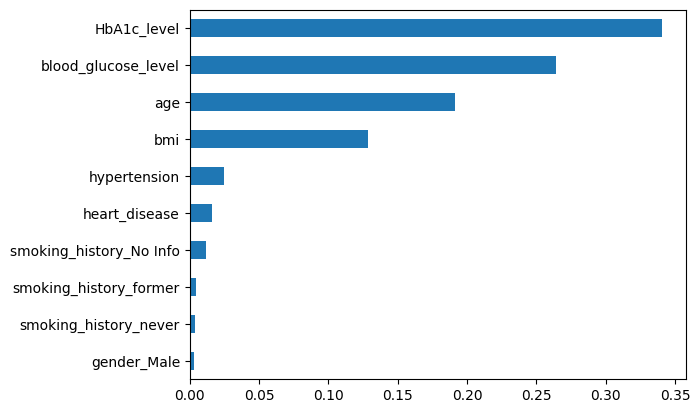

In [23]:
import matplotlib.pyplot as plt

feature_names = (num_cols +
    list(model.named_steps['prep'].named_transformers_['cat'].get_feature_names_out(cat_cols)) +
    ['hypertension','heart_disease'])

importances = model.named_steps['clf'].feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)
feat_imp.head(10).plot(kind='barh')
plt.gca().invert_yaxis()
plt.show()

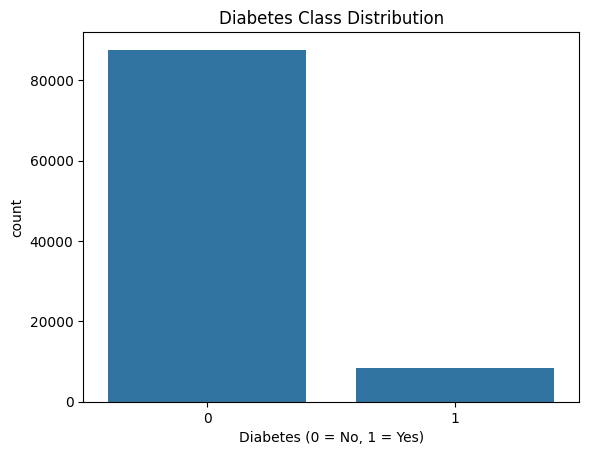

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='diabetes', data=df)
plt.title('Diabetes Class Distribution')
plt.xlabel('Diabetes (0 = No, 1 = Yes)')
plt.show()

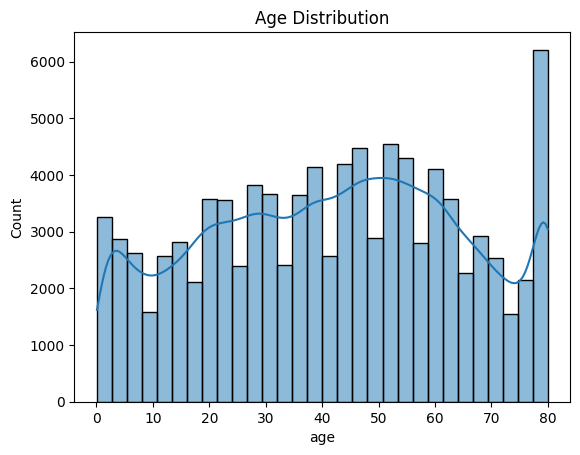

In [25]:
sns.histplot(df['age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.show()

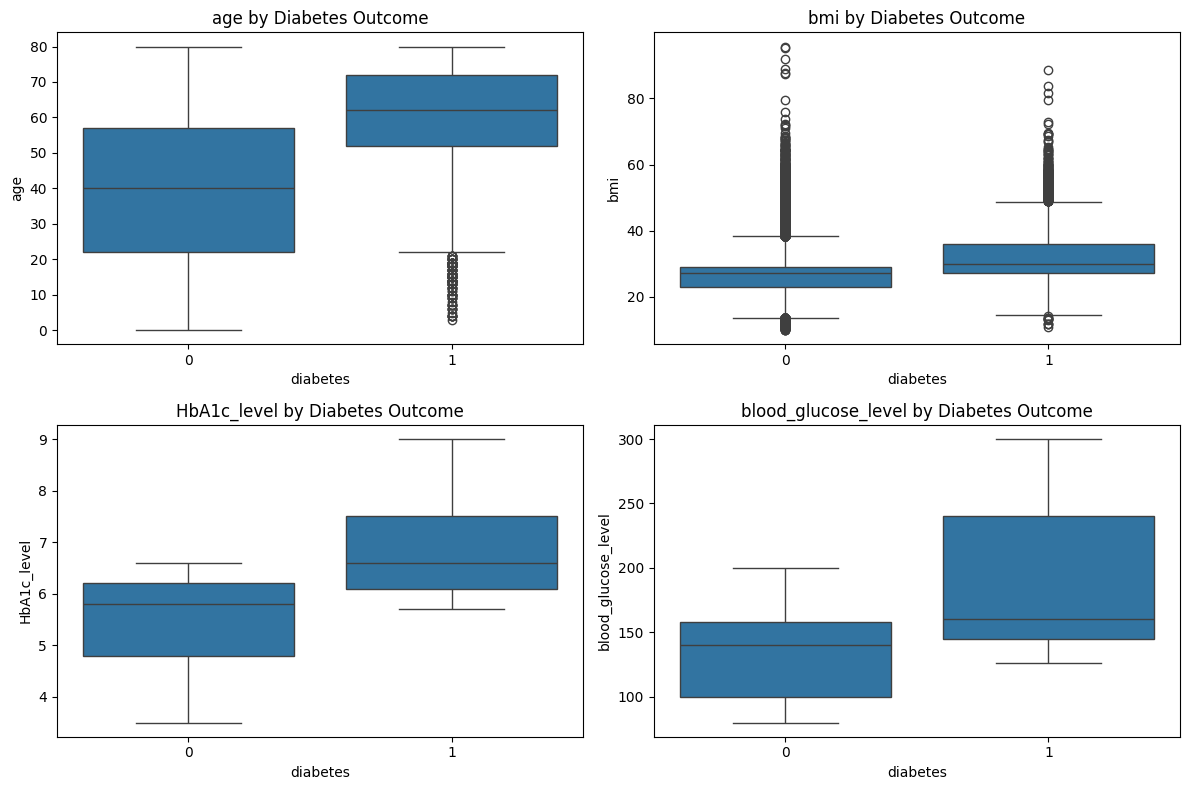

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(12,8))
for ax, col in zip(axes.flatten(), ['age','bmi','HbA1c_level','blood_glucose_level']):
    sns.boxplot(x='diabetes', y=col, data=df, ax=ax)
    ax.set_title(f'{col} by Diabetes Outcome')
plt.tight_layout()
plt.show()

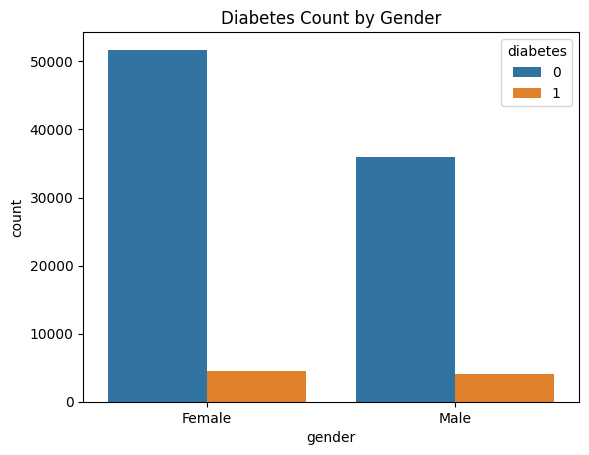

In [27]:
sns.countplot(x='gender', hue='diabetes', data=df)
plt.title('Diabetes Count by Gender')
plt.show()

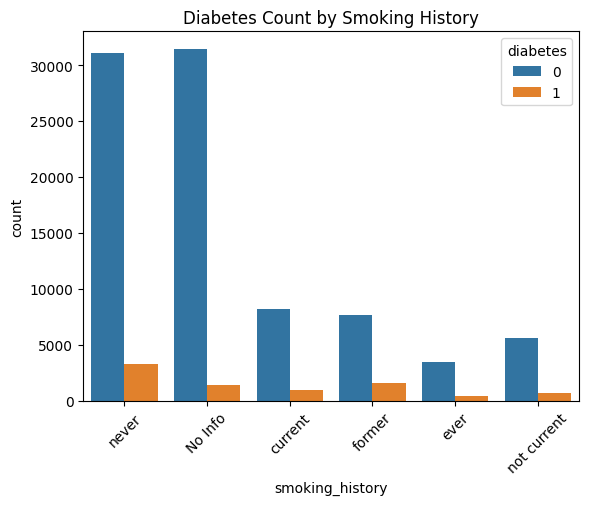

In [28]:
sns.countplot(x='smoking_history', hue='diabetes', data=df)
plt.xticks(rotation=45)
plt.title('Diabetes Count by Smoking History')
plt.show()

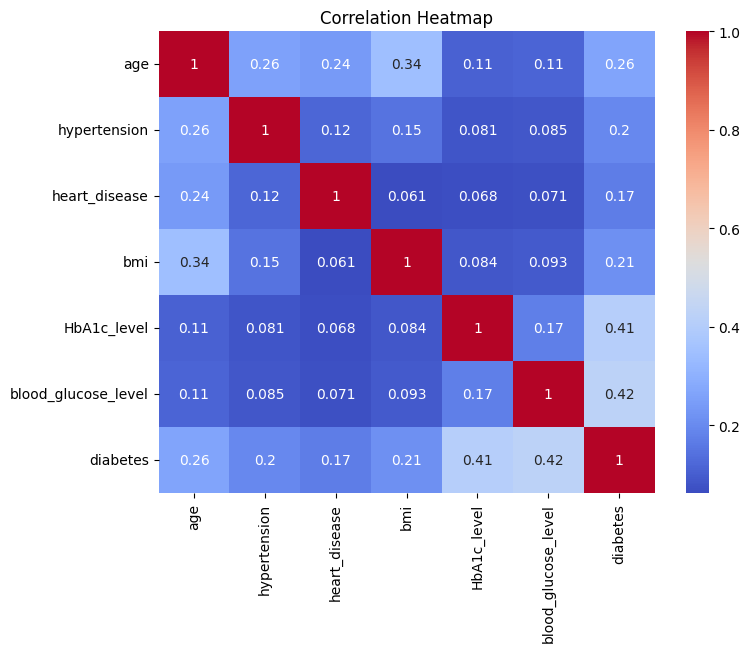

In [29]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

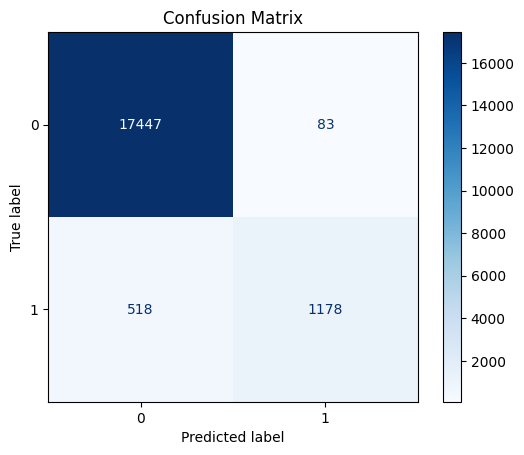

In [30]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

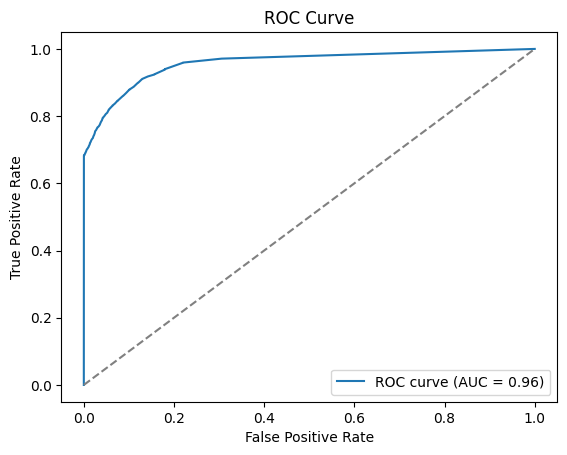

In [31]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:,1])
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()